In [ ]:
import os
import shutil

# Step 1: Create a folder named "ecg_data" in the current directory
os.makedirs("ecg_data", exist_ok=True)

# Step 2: Move all MIT-BIH files into that folder
for filename in os.listdir("/content"):
    if filename.endswith(('.dat', '.atr', '.hea', '.xws')):
        shutil.move(os.path.join("/content", filename), "ecg_data")



In [ ]:
# Check if files are inside ecg_data now
print(os.listdir("ecg_data"))


['223.atr', '111.dat', '215.atr', '124.hea', '215.xws', '209.hea', '201.hea', '221.dat', '115.xws', '117.xws', '100.dat', '232.dat', '214.dat', '230.xws', '100.atr', '101.dat', '114.hea', '219.hea', '200.xws', '123.dat', '213.xws', '102.dat', '104.xws', '200.atr', '222.dat', '107.hea', '203.dat', '213.atr', '210.dat', '106.atr', '215.hea', '210.xws', '212.dat', '202.dat', '109.xws', '208.xws', '115.hea', '233.atr', '222.xws', '222.atr', '100.xws', '228.hea', '118.atr', '214.xws', '217.xws', '207.xws', '214.atr', '205.dat', '123.atr', '102.hea', '233.hea', '103.dat', '103.xws', '223.hea', '113.xws', '234.hea', '232.hea', '111.hea', '208.dat', '121.atr', '111.xws', '106.xws', '208.hea', '112.dat', '205.xws', '113.dat', '121.xws', '214.hea', '201.atr', '113.hea', '212.atr', '213.dat', '107.xws', '205.atr', '114.dat', '118.dat', '208.atr', '234.xws', '203.atr', '122.atr', '101.atr', '231.atr', '118.hea', '223.dat', '108.dat', '121.hea', '124.atr', '231.xws', '115.atr', '223.xws', '220.xws'

In [ ]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 84.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [ ]:
import wfdb

data_dir = "ecg_data"

# Get all record names (excluding the file extension)
record_names = sorted(set(f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.dat')))

print("Found records:", record_names)

# Example: Read one sample record
record = wfdb.rdrecord(os.path.join(data_dir, record_names[0]))
annotation = wfdb.rdann(os.path.join(data_dir, record_names[0]), 'atr')

print("Sample data shape:", record.p_signal.shape)
print("Annotation symbols:", annotation.symbol[:10])


Found records: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']
Sample data shape: (650000, 2)
Annotation symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N']


In [ ]:
import os

# Path to your ECG dataset folder
data_dir = '/content/ecg_data'  # Change this to your local path if needed

# Get all `.dat` files and extract the record names (e.g., '232', '233')
record_names = [f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.dat')]

# Remove duplicates if multiple .dat per record
record_names = list(set(record_names))
print("Records:", record_names)


Records: ['217', '124', '232', '234', '223', '200', '121', '205', '215', '220', '108', '219', '114', '201', '103', '209', '207', '113', '106', '122', '214', '100', '102', '119', '222', '111', '210', '213', '228', '203', '107', '230', '115', '202', '221', '101', '123', '118', '105', '233', '208', '212', '231', '104', '116', '117', '112', '109']


In [ ]:
import wfdb
import numpy as np

all_beats = []
all_labels = []

window_size = 100

for record_name in record_names:
    try:
        record = wfdb.rdrecord(f'{data_dir}/{record_name}')
        annotation = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')

        signal = record.p_signal[:, 0]  # First channel
        r_peaks = annotation.sample
        labels = annotation.symbol

        for i in range(len(r_peaks)):
            idx = r_peaks[i]
            if idx - window_size > 0 and idx + window_size < len(signal):
                beat = signal[idx - window_size : idx + window_size]
                all_beats.append(beat)
                all_labels.append(labels[i])

    except Exception as e:
        print(f"Failed to process {record_name}: {e}")


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Optional: filter only a subset of labels you're interested in
# For example: only ['N', 'A', 'V', 'L', 'R']
filtered_beats = []
filtered_labels = []

allowed_labels = ['N', 'A', 'V', 'L', 'R']

for beat, label in zip(all_beats, all_labels):
    if label in allowed_labels:
        filtered_beats.append(beat)
        filtered_labels.append(label)

X = np.array(filtered_beats)
y = np.array(filtered_labels)

# Encode labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)


Classes: ['A' 'L' 'N' 'R' 'V']


In [ ]:
from sklearn.model_selection import train_test_split

X = X.reshape(X.shape[0], X.shape[1], 1)  # reshape for CNN
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

cnn_model = models.Sequential([
    layers.Conv1D(32, 5, activation='relu', input_shape=(X.shape[1], 1)),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, 5, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

history = cnn_model.fit(X_train, y_train, epochs=15, batch_size=32,
                        validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 44s 17ms/step - accuracy: 0.9258 - loss: 0.2630 - val_accuracy: 0.9743 - val_loss: 0.0977
Epoch 2/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9779 - loss: 0.0813 - val_accuracy: 0.9836 - val_loss: 0.0615
Epoch 3/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9845 - loss: 0.0580 - val_accuracy: 0.9852 - val_loss: 0.0585
Epoch 4/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9874 - loss: 0.0479 - val_accuracy: 0.9885 - val_loss: 0.0462
Epoch 5/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9898 - loss: 0.0368 - val_accuracy: 0.9891 - val_loss: 0.0456
Epoch 6/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - accuracy: 0.9910 - loss: 0.0314 - val_accuracy: 0.9883 - val_loss: 0.0445
Epoch 7/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9924 - loss: 0.0279 - val_accuracy: 0.9891 - val_loss: 0.0514
Epoch 8/15
2501/2501 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9934 -

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X_rf = X.reshape(X.shape[0], -1)
X_rf_train, X_rf_test, y_rf_train, y_rf_test = train_test_split(X_rf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_rf_train, y_rf_train)

rf_accuracy = rf_model.score(X_rf_test, y_rf_test)
print("Random Forest Accuracy:", rf_accuracy)


Random Forest Accuracy: 0.9847553356325286


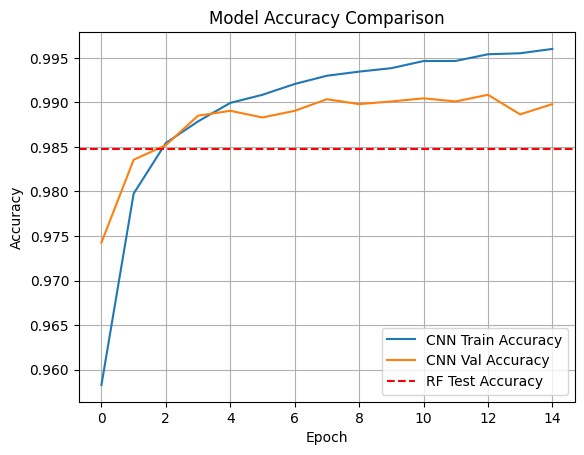

In [ ]:
import matplotlib.pyplot as plt

# CNN Accuracy
plt.plot(history.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history.history['val_accuracy'], label='CNN Val Accuracy')
plt.axhline(rf_accuracy, color='red', linestyle='--', label='RF Test Accuracy')
plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


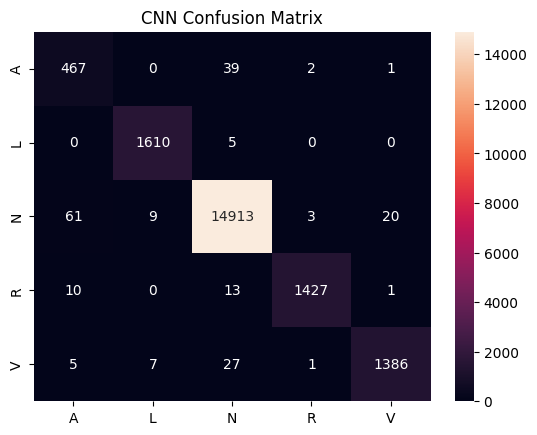

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_cnn = cnn_model.predict(X_test)
y_pred_labels = np.argmax(y_pred_cnn, axis=1)

cm = confusion_matrix(y_test, y_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("CNN Confusion Matrix")
plt.show()


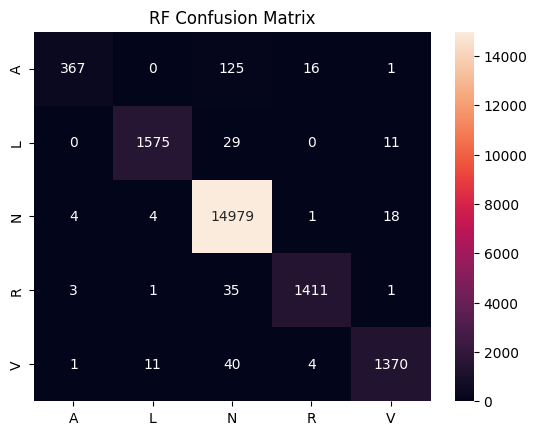

In [ ]:
y_rf_pred = rf_model.predict(X_rf_test)

cm_rf = confusion_matrix(y_rf_test, y_rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("RF Confusion Matrix")
plt.show()


In [ ]:
import numpy as np

# Predict probabilities on test set
cnn_preds = cnn_model.predict(X_test)

# Get the predicted class (highest probability)
cnn_pred_labels = np.argmax(cnn_preds, axis=1)

# Compare with actual labels
for i in range(10):  # Show 10 random samples
    print(f"Actual: {label_encoder.inverse_transform([y_test[i]])[0]} | Predicted: {label_encoder.inverse_transform([cnn_pred_labels[i]])[0]}")


626/626 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Actual: N | Predicted: N
Actual: R | Predicted: R
Actual: N | Predicted: N
Actual: N | Predicted: N
Actual: A | Predicted: A
Actual: N | Predicted: N
Actual: V | Predicted: V
Actual: L | Predicted: L
Actual: V | Predicted: V
Actual: R | Predicted: R


In [ ]:
rf_preds = rf_model.predict(X_rf_test)

for i in range(10):
    print(f"Actual: {label_encoder.inverse_transform([y_rf_test[i]])[0]} | Predicted: {label_encoder.inverse_transform([rf_preds[i]])[0]}")


Actual: N | Predicted: N
Actual: R | Predicted: R
Actual: N | Predicted: N
Actual: N | Predicted: N
Actual: A | Predicted: A
Actual: N | Predicted: N
Actual: V | Predicted: V
Actual: L | Predicted: L
Actual: V | Predicted: V
Actual: R | Predicted: R


In [ ]:
# Select one beat from the test set
# Correct reshape (matches original training shape)
new_beat = X_test[1]
new_beat_cnn = new_beat.reshape(1, 200, 1)
cnn_new_pred = cnn_model.predict(new_beat_cnn)
predicted_class = np.argmax(cnn_new_pred)
print("Predicted Class:", label_encoder.inverse_transform([predicted_class])[0])




1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Predicted Class: R


In [ ]:
new_beat_rf = X_rf_test[1].reshape(1, -1)
rf_new_pred = rf_model.predict(new_beat_rf)
print("Predicted Class:", label_encoder.inverse_transform(rf_new_pred)[0])


Predicted Class: R
